In [5]:
import pandas
import os

# This query represents dataset "Expanded_Labs_Vitals_LongFormat" for domain "measurement" and was generated for All of Us Controlled Tier Dataset v8
dataset_74044708_measurement_sql = """
SELECT
    measurement.person_id,
    measurement.measurement_concept_id,
    m_standard_concept.concept_name as standard_concept_name,
    measurement.measurement_datetime,
    measurement.value_as_number,
    m_unit.concept_name as unit_concept_name 
FROM
    (
    SELECT
        *
    FROM
        `""" + os.environ["WORKSPACE_CDR"] + """.measurement` measurement
    WHERE
        measurement_concept_id IN (
            SELECT DISTINCT c.concept_id
            FROM `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` c
            JOIN (
                SELECT CAST(cr.id as string) AS id
                FROM `""" + os.environ["WORKSPACE_CDR"] + """.cb_criteria` cr
                WHERE concept_id IN (
                    3002385,3004249,3004410,3005673,3006906,3007461,
                    3010156,3012888,3016723,3019550,3019897,3020149,
                    3020460,3023103,3024561,3024929,3038553,40765040,40795725
                )
                AND full_text LIKE '%_rank1]%'
            ) a
            ON (c.path LIKE CONCAT('%.', a.id, '.%')
                OR c.path LIKE CONCAT('%.', a.id)
                OR c.path LIKE CONCAT(a.id, '.%')
                OR c.path = a.id)
            WHERE is_standard = 1
            AND is_selectable = 1
        )

        AND measurement.person_id IN (
            SELECT DISTINCT person_id
            FROM `""" + os.environ["WORKSPACE_CDR"] + """.cb_search_person`
        )

        -- EXCLUDE DECEASED PARTICIPANTS (same logic as old notebook)
        AND measurement.person_id NOT IN (
            SELECT person_id
            FROM `""" + os.environ["WORKSPACE_CDR"] + """.death`
        )

    ) measurement

LEFT JOIN `""" + os.environ["WORKSPACE_CDR"] + """.concept` m_standard_concept
    ON measurement.measurement_concept_id = m_standard_concept.concept_id

LEFT JOIN `""" + os.environ["WORKSPACE_CDR"] + """.concept` m_unit
    ON measurement.unit_concept_id = m_unit.concept_id

WHERE
(
    -- BMI
    (m_standard_concept.concept_name = 'Body mass index (BMI) [Ratio]'
        AND m_unit.concept_name IN ('kilogram per square meter','kg/sq. m')
        AND measurement.value_as_number BETWEEN 10 AND 80)

    OR

    -- Systolic BP
    (m_standard_concept.concept_name = 'Systolic blood pressure'
        AND m_unit.concept_name = 'millimeter mercury column'
        AND measurement.value_as_number BETWEEN 70 AND 250)

    OR

    -- Diastolic BP
    (m_standard_concept.concept_name = 'Diastolic blood pressure'
        AND m_unit.concept_name = 'millimeter mercury column'
        AND measurement.value_as_number BETWEEN 40 AND 150)

    OR

    -- Sodium
    (m_standard_concept.concept_name = 'Sodium [Moles/volume] in Serum or Plasma'
        AND m_unit.concept_name = 'millimole per liter'
        AND measurement.value_as_number BETWEEN 110 AND 170)

    OR

    -- Potassium
    (m_standard_concept.concept_name = 'Potassium [Moles/volume] in Serum or Plasma'
        AND m_unit.concept_name = 'millimole per liter'
        AND measurement.value_as_number BETWEEN 2 AND 7)

    OR

    -- Creatinine
    (m_standard_concept.concept_name = 'Creatinine [Mass/volume] in Serum or Plasma'
        AND m_unit.concept_name = 'milligram per deciliter'
        AND measurement.value_as_number BETWEEN 0.2 AND 15)

    OR

    -- Hemoglobin
    (m_standard_concept.concept_name = 'Hemoglobin [Mass/volume] in Blood'
        AND m_unit.concept_name = 'gram per liter'
        AND measurement.value_as_number BETWEEN 50 AND 200)

    OR

    -- RDW
    (m_standard_concept.concept_name LIKE 'Erythrocyte distribution width%'
        AND measurement.value_as_number BETWEEN 10 AND 30)

    OR

    -- Albumin
    (m_standard_concept.concept_name = 'Albumin [Mass/volume] in Serum or Plasma'
        AND m_unit.concept_name = 'gram per liter'
        AND measurement.value_as_number BETWEEN 10 AND 60)

    OR

    -- HbA1c
    (m_standard_concept.concept_name LIKE 'Hemoglobin A1c%'
        AND m_unit.concept_name LIKE '%percent%'
        AND measurement.value_as_number BETWEEN 3 AND 18)

    OR

    -- Vitamin D
    (LOWER(m_standard_concept.concept_name) LIKE '25-%vitamin%'
        AND m_unit.concept_name = 'nanogram per milliliter'
        AND measurement.value_as_number BETWEEN 5 AND 150)

    OR

    -- CRP
    (LOWER(m_standard_concept.concept_name) LIKE 'c reactive protein%'
        AND measurement.value_as_number BETWEEN 0 AND 300)
)
"""

dataset_74044708_measurement_df = pandas.read_gbq(
    dataset_74044708_measurement_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

measurement_expanded_df = dataset_74044708_measurement_df

Downloading:   0%|          | 0/61490458 [00:00<?, ?rows/s]

In [6]:
measurement_expanded_df.to_parquet(
    "measurement_raw_expanded.parquet",
    index=False
)

In [7]:
measurement_expanded_df.shape

(61490458, 6)

In [8]:
measurement_expanded_df.groupby("standard_concept_name")["person_id"].nunique().sort_values(ascending=False)

standard_concept_name
Body mass index (BMI) [Ratio]                                                     487514
Diastolic blood pressure                                                          469497
Systolic blood pressure                                                           469470
Hemoglobin [Mass/volume] in Blood                                                 266238
Sodium [Moles/volume] in Serum or Plasma                                          261976
Potassium [Moles/volume] in Serum or Plasma                                       261744
Creatinine [Mass/volume] in Serum or Plasma                                       257190
Erythrocyte distribution width [Ratio] by Automated count                         254516
Albumin [Mass/volume] in Serum or Plasma                                          223298
Hemoglobin A1c/Hemoglobin.total in Blood                                          129122
25-hydroxyvitamin D3 [Mass/volume] in Serum or Plasma                              76274

In [1]:
import pandas as pd
measurement_df = pd.read_parquet("measurement_raw_expanded.parquet")
mobility_df = pd.read_parquet("mobility_condition_raw.parquet")

## Define TRUE case index dates

In [10]:
mobility_first = (
    mobility_df
    .groupby("person_id")["condition_start_datetime"]
    .min()
    .reset_index()
)

mobility_first = mobility_first.rename(
    columns={"condition_start_datetime": "decline_date"}
)

mobility_first.to_parquet("mobility_first_index.parquet", index=False)

mobility_first.shape

(36787, 2)

## Restrict to Cases Who Have Labs

In [11]:
lab_ids = set(measurement_df["person_id"].unique())
case_ids = set(mobility_first["person_id"])

case_ids_with_labs = case_ids & lab_ids

len(case_ids_with_labs)

35049

In [12]:
cases_df = mobility_first[
    mobility_first["person_id"].isin(case_ids_with_labs)
].copy()

cases_df["label"] = 1

cases_df.shape

(35049, 3)

## Define CLEAN CONTROL POOL

In [13]:
control_ids = lab_ids - case_ids_with_labs

len(control_ids)

controls_df = pd.DataFrame({
    "person_id": list(control_ids),
    "label": 0
})

controls_df.shape

(476948, 2)

## Build Observation Windows

In [14]:
observation_windows = (
    measurement_df
    .groupby("person_id")["measurement_datetime"]
    .agg(["min", "max"])
    .reset_index()
)

observation_windows.columns = [
    "person_id",
    "first_lab",
    "last_lab"
]

observation_windows.shape

(511997, 3)

In [15]:
observation_windows.to_parquet("observation_windows_expanded.parquet", index=False)

## Build Random Pseudo Index for Controls

In [16]:
controls_df = controls_df.merge(
    observation_windows,
    on="person_id",
    how="left"
)

controls_df.shape

(476948, 4)

In [17]:
import numpy as np

np.random.seed(42)

controls_df["first_lab"] = pd.to_datetime(controls_df["first_lab"])
controls_df["last_lab"]  = pd.to_datetime(controls_df["last_lab"])

controls_df["window_days"] = (
    controls_df["last_lab"] - controls_df["first_lab"]
).dt.days

controls_df = controls_df[controls_df["window_days"] > 0]

controls_df["random_offset"] = np.random.randint(
    0,
    controls_df["window_days"] + 1
)

controls_df["decline_date"] = (
    controls_df["first_lab"] +
    pd.to_timedelta(controls_df["random_offset"], unit="D")
)

controls_df.shape

(287360, 7)

## Merge Observation Windows to Cases

In [18]:
cases_df = cases_df.merge(
    observation_windows,
    on="person_id",
    how="left"
)

cases_df.shape

(35049, 5)

In [19]:
pseudo_cohort = pd.concat(
    [
        cases_df[["person_id", "decline_date", "label"]],
        controls_df[["person_id", "decline_date", "label"]]
    ],
    ignore_index=True
)

pseudo_cohort.shape

(322409, 3)

In [20]:
pseudo_cohort.to_parquet("pseudo_cohort_expanded.parquet", index=False)

In [21]:
pseudo_cohort["label"].value_counts(normalize=True)

label
0    0.89129
1    0.10871
Name: proportion, dtype: float64

In [22]:
pseudo_cohort["decline_date"].isna().sum()

0

## Missingness Analysis

Examine whether measurement availability differs systematically between cases and controls. Differential missingness may indicate ascertainment bias (sicker patients receive more labs).

In [7]:
# Merge labs with pseudo cohort to assess missingness
labs_for_missing = measurement_df.merge(
    pseudo_cohort,
    on="person_id",
    how="inner"
)

labs_for_missing["measurement_datetime"] = pd.to_datetime(labs_for_missing["measurement_datetime"])
labs_for_missing["decline_date"] = pd.to_datetime(labs_for_missing["decline_date"])

# Restrict to pre-index 3-year window
labs_for_missing = labs_for_missing[
    (labs_for_missing["measurement_datetime"] < labs_for_missing["decline_date"]) &
    (labs_for_missing["measurement_datetime"] >= labs_for_missing["decline_date"] - pd.DateOffset(years=3))
]

wide_for_missing = (
    labs_for_missing
    .groupby(["person_id", "standard_concept_name"])["value_as_number"]
    .mean()
    .unstack()
    .reset_index()
)

wide_for_missing = wide_for_missing.merge(
    pseudo_cohort[["person_id","label"]],
    on="person_id",
    how="left"
)

feature_cols = [
    c for c in wide_for_missing.columns
    if c not in ["person_id","label"]
]

missing_by_label = pd.DataFrame({
    "Cases": wide_for_missing[wide_for_missing["label"]==1][feature_cols].isna().mean(),
    "Controls": wide_for_missing[wide_for_missing["label"]==0][feature_cols].isna().mean()
})

missing_by_label = missing_by_label.sort_values("Cases", ascending=False)

missing_by_label

,Cases,Controls
Erythrocyte distribution width [Ratio],0.961648,0.963678
C reactive protein [Mass/volume] in Serum or Plasma by High sensitivity method,0.927224,0.977165
25-Hydroxyvitamin D3+25-Hydroxyvitamin D2 [Mass/volume] in Serum or Plasma,0.875423,0.941833
Hemoglobin A1c/Hemoglobin.total in Blood by HPLC,0.874486,0.939469
C reactive protein [Mass/volume] in Serum or Plasma,0.816096,0.926499
25-hydroxyvitamin D3 [Mass/volume] in Serum or Plasma,0.795424,0.896383
Hemoglobin A1c/Hemoglobin.total in Blood,0.605688,0.791421
Body mass index (BMI) [Ratio],0.401475,0.511011
Diastolic blood pressure,0.387845,0.386916
Systolic blood pressure,0.387754,0.386829


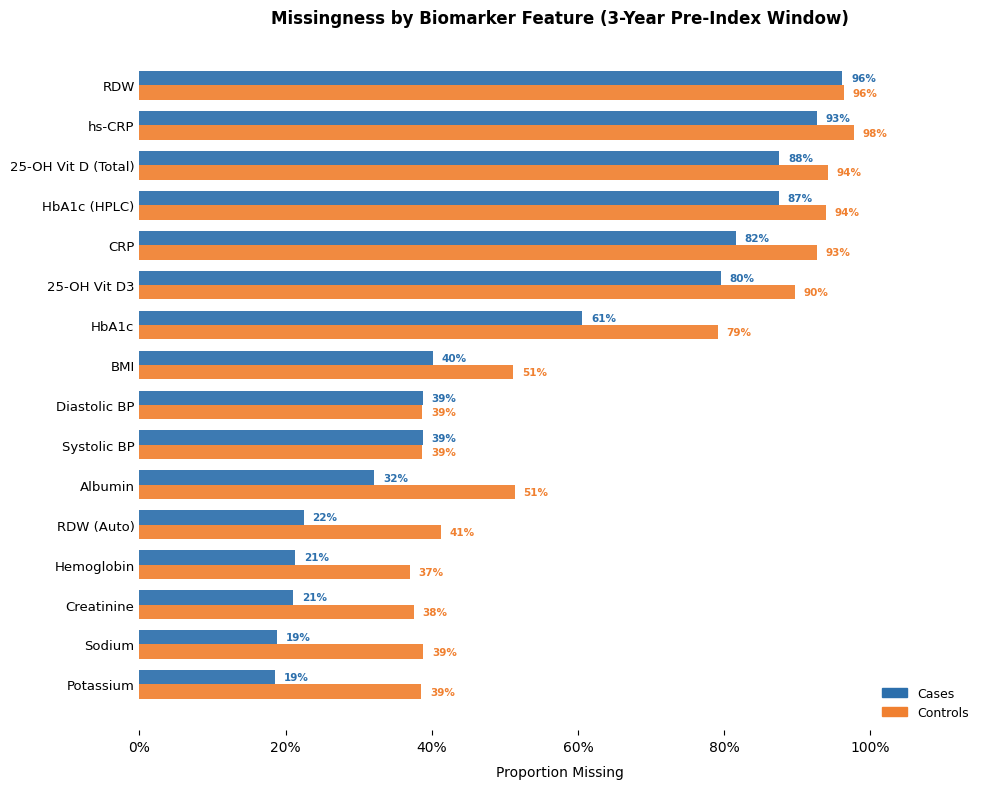

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

rename_map = {
    "Body mass index (BMI) [Ratio]": "BMI",
    "Systolic blood pressure": "Systolic BP",
    "Diastolic blood pressure": "Diastolic BP",
    "Sodium [Moles/volume] in Serum or Plasma": "Sodium",
    "Potassium [Moles/volume] in Serum or Plasma": "Potassium",
    "Creatinine [Mass/volume] in Serum or Plasma": "Creatinine",
    "Hemoglobin [Mass/volume] in Blood": "Hemoglobin",
    "Albumin [Mass/volume] in Serum or Plasma": "Albumin",
    "Erythrocyte distribution width [Ratio]": "RDW",
    "Erythrocyte distribution width [Ratio] by Automated count": "RDW (Auto)",
    "Hemoglobin A1c/Hemoglobin.total in Blood": "HbA1c",
    "Hemoglobin A1c/Hemoglobin.total in Blood by HPLC": "HbA1c (HPLC)",
    "25-hydroxyvitamin D3 [Mass/volume] in Serum or Plasma": "25-OH Vit D3",
    "25-Hydroxyvitamin D3+25-Hydroxyvitamin D2 [Mass/volume] in Serum or Plasma": "25-OH Vit D (Total)",
    "C reactive protein [Mass/volume] in Serum or Plasma": "CRP",
    "C reactive protein [Mass/volume] in Serum or Plasma by High sensitivity method": "hs-CRP"
}

plot_df = missing_by_label.copy()
plot_df.index = [rename_map.get(i, i) for i in plot_df.index]
plot_df = plot_df.iloc[::-1]

labels   = plot_df.index.tolist()
cases    = plot_df["Cases"].values
controls = plot_df["Controls"].values

n = len(labels)
y = np.arange(n)
bar_h = 0.36

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(y + bar_h / 2, cases,    height=bar_h, color="#2C6FAC", alpha=0.92, zorder=3)
ax.barh(y - bar_h / 2, controls, height=bar_h, color="#F08030", alpha=0.92, zorder=3)

for i, (c, ctrl) in enumerate(zip(cases, controls)):
    ax.text(c    + 0.012, y[i] + bar_h / 2, f"{c*100:.0f}%",
            va="center", ha="left", fontsize=7.5, color="#2C6FAC", fontweight="semibold")
    ax.text(ctrl + 0.012, y[i] - bar_h / 2, f"{ctrl*100:.0f}%",
            va="center", ha="left", fontsize=7.5, color="#F08030", fontweight="semibold")

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=9.5)
ax.set_xlim(0, 1.15)
ax.set_xlabel("Proportion Missing", fontsize=10, labelpad=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
ax.tick_params(axis="y", length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("Missingness by Biomarker Feature (3-Year Pre-Index Window)", fontsize=12, fontweight="bold", pad=12)

ax.legend(
    handles=[mpatches.Patch(color="#2C6FAC", label="Cases"),
             mpatches.Patch(color="#F08030", label="Controls")],
    loc="lower right", fontsize=9, frameon=False
)

plt.tight_layout()
plt.savefig("missingness_expanded.png", dpi=300, bbox_inches="tight")
plt.show()

## Merge Labs With Cohort

In [25]:
labs = measurement_df.merge(
    pseudo_cohort,
    on="person_id",
    how="inner"
)

labs.shape

(60397055, 8)

## Remove Leakage

In [26]:
labs["measurement_datetime"] = pd.to_datetime(labs["measurement_datetime"]).dt.tz_localize(None)
labs["decline_date"] = pd.to_datetime(labs["decline_date"]).dt.tz_localize(None)

labs_preindex = labs[
    labs["measurement_datetime"] < labs["decline_date"]
].copy()

labs_preindex.shape

(28124596, 8)

In [27]:
labs_preindex.to_parquet("labs_preindex_pseudo_expanded.parquet", index=False)

## Create 2-Year and 3-year Window

In [28]:
labs_2yr = labs_preindex[
    labs_preindex["measurement_datetime"] >=
    labs_preindex["decline_date"] - pd.DateOffset(years=2)
].copy()

labs_2yr.shape

(12175724, 8)

In [29]:
labs_2yr.to_parquet(
    "labs_2yr_pseudo_expanded.parquet",
    index=False
)

In [30]:
labs_3yr = labs_preindex[
    labs_preindex["measurement_datetime"] >=
    labs_preindex["decline_date"] - pd.DateOffset(years=3)
].copy()

labs_3yr.shape

(15936931, 8)

In [31]:
labs_3yr.to_parquet(
    "labs_3yr_pseudo_expanded.parquet",
    index=False
)

In [32]:
print("Unique persons 2yr:", labs_2yr["person_id"].nunique())
print("Unique persons 3yr:", labs_3yr["person_id"].nunique())
print("Total pseudo cohort:", pseudo_cohort["person_id"].nunique())

Unique persons 2yr: 282261
Unique persons 3yr: 297861
Total pseudo cohort: 322409


In [33]:
labs_2yr[["person_id","label"]].drop_duplicates()["label"].value_counts()

label
0    249719
1     32542
Name: count, dtype: int64

In [34]:
labs_3yr[["person_id","label"]].drop_duplicates()["label"].value_counts()

label
0    264773
1     33088
Name: count, dtype: int64

N = 282,261
Cases = 32,542 (11.5%)
Controls = 249,719

N = 297,861
Cases = 33,088 (11.1%)
Controls = 264,773

## Build Baseline Features

In [35]:
# 2 yr
baseline_2yr_expanded = (
    labs_2yr
    .groupby(["person_id", "standard_concept_name"])
    .agg(mean_value=("value_as_number", "mean"))
    .reset_index()
)

baseline_2yr_wide_expanded = baseline_2yr_expanded.pivot(
    index="person_id",
    columns="standard_concept_name",
    values="mean_value"
).reset_index()

baseline_2yr_wide_expanded = baseline_2yr_wide_expanded.merge(
    labs_2yr[["person_id","label"]].drop_duplicates(),
    on="person_id",
    how="left"
)

baseline_2yr_wide_expanded.shape

(282261, 18)

In [36]:
# 3 yr
baseline_3yr_expanded = (
    labs_3yr
    .groupby(["person_id", "standard_concept_name"])
    .agg(mean_value=("value_as_number", "mean"))
    .reset_index()
)

baseline_3yr_wide_expanded = baseline_3yr_expanded.pivot(
    index="person_id",
    columns="standard_concept_name",
    values="mean_value"
).reset_index()

baseline_3yr_wide_expanded = baseline_3yr_wide_expanded.merge(
    labs_3yr[["person_id","label"]].drop_duplicates(),
    on="person_id",
    how="left"
)

baseline_3yr_wide_expanded.shape

(297861, 18)

In [37]:
baseline_2yr_wide_expanded.to_parquet(
    "baseline_2yr_wide_expanded.parquet",
    index=False
)

In [38]:
baseline_3yr_wide_expanded.to_parquet(
    "baseline_3yr_wide_expanded.parquet",
    index=False
)

##  5-Fold CV on baseline features

In [39]:
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import numpy as np

def run_model_cv(df, model_name="Model", n_splits=5, random_state=42):

    X = df.drop(columns=["person_id", "label"])
    y = df["label"]

    mask = ~X.isna().all(axis=1)
    X = X[mask]
    y = y[mask]

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    aucs = []

    print(f"\n===== {model_name} =====")

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

        X_train_raw = X.iloc[train_idx]
        X_test_raw  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test  = y.iloc[test_idx]

        imputer = SimpleImputer(strategy="median")
        X_train = imputer.fit_transform(X_train_raw)
        X_test  = imputer.transform(X_test_raw)

        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

        model = lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            verbose=-1
        )

        model.fit(X_train, y_train)

        y_pred = model.predict_proba(X_test)[:,1]

        auc = roc_auc_score(y_test, y_pred)
        aucs.append(auc)

        print(f"Fold {fold}: AUC = {auc:.4f}")

    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    print(f"\nMean AUC: {mean_auc:.4f} ± {std_auc:.4f}")

    return mean_auc, std_auc

In [40]:
b2_mean_exp, b2_std_exp = run_model_cv(
    baseline_2yr_wide_expanded,
    model_name="Expanded Baseline 2-Year"
)


===== Expanded Baseline 2-Year =====


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: AUC = 0.7495


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: AUC = 0.7459


...

Fold 3: AUC = 0.7455


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4: AUC = 0.7369


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5: AUC = 0.7448

Mean AUC: 0.7445 ± 0.0041


In [41]:
b3_mean_exp, b3_std_exp = run_model_cv(
    baseline_3yr_wide_expanded,
    model_name="Expanded Baseline 3-Year"
)


===== Expanded Baseline 3-Year =====


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: AUC = 0.7579


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: AUC = 0.7515


...

Fold 3: AUC = 0.7574


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4: AUC = 0.7525


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5: AUC = 0.7545

Mean AUC: 0.7548 ± 0.0026


## Build Trajectory Features (with Slope)

Trajectory features capture longitudinal dynamics beyond cross-sectional means:
- **mean**: average value in the observation window
- **std**: within-person variability
- **delta**: last − first value (total change)
- **slope**: linear regression slope of value vs. days-before-index (rate of change per day)
- **count**: number of measurements (utilization proxy)

In [42]:
# ── 2-Year Trajectory Features (Expanded) ─────────────────────────────

import numpy as np

labs_2yr["measurement_datetime"] = pd.to_datetime(labs_2yr["measurement_datetime"])
labs_2yr["decline_date"] = pd.to_datetime(labs_2yr["decline_date"])

labs_2yr["days_before_index"] = (
    labs_2yr["decline_date"] - labs_2yr["measurement_datetime"]
).dt.days

labs_2yr = labs_2yr.sort_values(
    ["person_id","standard_concept_name","measurement_datetime"]
)

# Basic aggregation
agg_basic_2yr_expanded = (
    labs_2yr
    .groupby(["person_id","standard_concept_name"])
    .agg(
        mean=("value_as_number","mean"),
        std=("value_as_number","std"),
        first_val=("value_as_number","first"),
        last_val=("value_as_number","last"),
        count=("value_as_number","count")
    )
)

# Slope calculation
labs_2yr["xy"] = labs_2yr["days_before_index"] * labs_2yr["value_as_number"]
labs_2yr["xx"] = labs_2yr["days_before_index"] ** 2

agg_slope_2yr_expanded = (
    labs_2yr
    .groupby(["person_id","standard_concept_name"])
    .agg(
        sum_x=("days_before_index","sum"),
        sum_y=("value_as_number","sum"),
        sum_xy=("xy","sum"),
        sum_xx=("xx","sum"),
        n=("value_as_number","count")
    )
)

numerator = (
    agg_slope_2yr_expanded["n"] * agg_slope_2yr_expanded["sum_xy"]
    - agg_slope_2yr_expanded["sum_x"] * agg_slope_2yr_expanded["sum_y"]
)

denominator = (
    agg_slope_2yr_expanded["n"] * agg_slope_2yr_expanded["sum_xx"]
    - agg_slope_2yr_expanded["sum_x"] ** 2
)

agg_slope_2yr_expanded["slope"] = numerator / denominator
agg_slope_2yr_expanded.loc[denominator == 0, "slope"] = np.nan

trajectory_2yr_expanded = agg_basic_2yr_expanded.join(
    agg_slope_2yr_expanded["slope"]
)

trajectory_2yr_expanded["delta"] = (
    trajectory_2yr_expanded["last_val"]
    - trajectory_2yr_expanded["first_val"]
)

trajectory_2yr_expanded = trajectory_2yr_expanded.reset_index()

print("2yr trajectory expanded shape:", trajectory_2yr_expanded.shape)

2yr trajectory expanded shape: (1636445, 9)


In [43]:
traj_2yr_long_expanded = trajectory_2yr_expanded.melt(
    id_vars=["person_id","standard_concept_name"],
    value_vars=["mean","std","delta","slope","count"],
    var_name="metric",
    value_name="value"
)

traj_2yr_long_expanded["feature"] = (
    traj_2yr_long_expanded["standard_concept_name"]
    .str.replace(r"[^A-Za-z0-9]+","_",regex=True)
    + "_" +
    traj_2yr_long_expanded["metric"]
)

traj_2yr_wide_expanded = traj_2yr_long_expanded.pivot(
    index="person_id",
    columns="feature",
    values="value"
).reset_index()

traj_2yr_wide_expanded = traj_2yr_wide_expanded.merge(
    labs_2yr[["person_id","label"]].drop_duplicates(),
    on="person_id",
    how="left"
)

traj_2yr_wide_expanded.to_parquet(
    "traj_2yr_wide_expanded.parquet",
    index=False
)

print("2yr trajectory wide expanded shape:", traj_2yr_wide_expanded.shape)

2yr trajectory wide expanded shape: (282261, 82)


In [44]:
traj_2yr_wide_expanded.to_parquet("traj_2yr_wide_expanded.parquet", index=False)

In [45]:
# ── 3-Year Trajectory Features (Expanded) ─────────────────────────────

labs_3yr["measurement_datetime"] = pd.to_datetime(labs_3yr["measurement_datetime"])
labs_3yr["decline_date"] = pd.to_datetime(labs_3yr["decline_date"])

labs_3yr["days_before_index"] = (
    labs_3yr["decline_date"] - labs_3yr["measurement_datetime"]
).dt.days

labs_3yr = labs_3yr.sort_values(
    ["person_id","standard_concept_name","measurement_datetime"]
)

agg_basic_3yr_expanded = (
    labs_3yr
    .groupby(["person_id","standard_concept_name"])
    .agg(
        mean=("value_as_number","mean"),
        std=("value_as_number","std"),
        first_val=("value_as_number","first"),
        last_val=("value_as_number","last"),
        count=("value_as_number","count")
    )
)

labs_3yr["xy"] = labs_3yr["days_before_index"] * labs_3yr["value_as_number"]
labs_3yr["xx"] = labs_3yr["days_before_index"] ** 2

agg_slope_3yr_expanded = (
    labs_3yr
    .groupby(["person_id","standard_concept_name"])
    .agg(
        sum_x=("days_before_index","sum"),
        sum_y=("value_as_number","sum"),
        sum_xy=("xy","sum"),
        sum_xx=("xx","sum"),
        n=("value_as_number","count")
    )
)

num = (
    agg_slope_3yr_expanded["n"] * agg_slope_3yr_expanded["sum_xy"]
    - agg_slope_3yr_expanded["sum_x"] * agg_slope_3yr_expanded["sum_y"]
)

den = (
    agg_slope_3yr_expanded["n"] * agg_slope_3yr_expanded["sum_xx"]
    - agg_slope_3yr_expanded["sum_x"] ** 2
)

agg_slope_3yr_expanded["slope"] = num / den
agg_slope_3yr_expanded.loc[den == 0,"slope"] = np.nan

trajectory_3yr_expanded = agg_basic_3yr_expanded.join(
    agg_slope_3yr_expanded["slope"]
)

trajectory_3yr_expanded["delta"] = (
    trajectory_3yr_expanded["last_val"]
    - trajectory_3yr_expanded["first_val"]
)

trajectory_3yr_expanded = trajectory_3yr_expanded.reset_index()

print("3yr trajectory expanded shape:", trajectory_3yr_expanded.shape)

3yr trajectory expanded shape: (1797025, 9)


In [46]:
traj_3yr_long_expanded = trajectory_3yr_expanded.melt(
    id_vars=["person_id","standard_concept_name"],
    value_vars=["mean","std","delta","slope","count"],
    var_name="metric",
    value_name="value"
)

traj_3yr_long_expanded["feature"] = (
    traj_3yr_long_expanded["standard_concept_name"]
    .str.replace(r"[^A-Za-z0-9]+","_",regex=True)
    + "_" +
    traj_3yr_long_expanded["metric"]
)

traj_3yr_wide_expanded = traj_3yr_long_expanded.pivot(
    index="person_id",
    columns="feature",
    values="value"
).reset_index()

traj_3yr_wide_expanded = traj_3yr_wide_expanded.merge(
    labs_3yr[["person_id","label"]].drop_duplicates(),
    on="person_id",
    how="left"
)

traj_3yr_wide_expanded.to_parquet(
    "traj_3yr_wide_expanded.parquet",
    index=False
)

print("3yr trajectory wide expanded shape:", traj_3yr_wide_expanded.shape)

3yr trajectory wide expanded shape: (297861, 82)


In [47]:
traj_3yr_wide_expanded.to_parquet("traj_3yr_wide_expanded.parquet", index=False)

## 5-Fold CV on Trajectory Models

In [48]:
t2_mean_exp, t2_std_exp = run_model_cv(
    traj_2yr_wide_expanded,
    model_name="Expanded Trajectory 2-Year"
)

t3_mean_exp, t3_std_exp = run_model_cv(
    traj_3yr_wide_expanded,
    model_name="Expanded Trajectory 3-Year"
)


===== Expanded Trajectory 2-Year =====


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: AUC = 0.7880


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: AUC = 0.7889


...

Fold 3: AUC = 0.8007


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4: AUC = 0.7949


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5: AUC = 0.7956

Mean AUC: 0.7971 ± 0.0020


## Multi-Model Comparison

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

def run_multiple_models_cv(df, label="Dataset"):

    from sklearn.model_selection import StratifiedKFold
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import roc_auc_score
    import numpy as np

    X = df.drop(columns=["person_id","label"])
    y = df["label"]

    mask = ~X.isna().all(axis=1)
    X = X[mask]
    y = y[mask]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
        "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", n_jobs=-1),
        "XGBoost": xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, eval_metric="auc", use_label_encoder=False),
        "LightGBM": lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05)
    }

    print(f"\n===== {label} =====")

    for name, model in models.items():

        aucs = []

        for train_idx, test_idx in skf.split(X,y):

            X_train_raw = X.iloc[train_idx]
            X_test_raw  = X.iloc[test_idx]
            y_train = y.iloc[train_idx]
            y_test  = y.iloc[test_idx]

            imputer = SimpleImputer(strategy="median")
            X_train = imputer.fit_transform(X_train_raw)
            X_test  = imputer.transform(X_test_raw)

            if name == "Logistic Regression":
                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test  = scaler.transform(X_test)

            scale_pos_weight = (y_train==0).sum()/(y_train==1).sum()

            if name == "LightGBM":
                model.set_params(scale_pos_weight=scale_pos_weight)
            if name == "XGBoost":
                model.set_params(scale_pos_weight=scale_pos_weight)

            model.fit(X_train,y_train)
            y_pred = model.predict_proba(X_test)[:,1]

            aucs.append(roc_auc_score(y_test,y_pred))

        print(f"{name}: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")

In [50]:
run_multiple_models_cv(
    baseline_3yr_wide_expanded,
    "Expanded Baseline 3yr"
)

run_multiple_models_cv(
    traj_3yr_wide_expanded,
    "Expanded Trajectory 3yr"
)


===== Expanded Baseline 3yr =====
Logistic Regression: 0.6403 ± 0.0016
Random Forest: 0.7136 ± 0.0023


/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:16:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:16:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:17:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:17:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:17:06] WARNING: /w

XGBoost: 0.7499 ± 0.0022


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: 0.7551 ± 0.0023

===== Expanded Trajectory 3yr =====
Logistic Regression: 0.7264 ± 0.0028
Random Forest: 0.7753 ± 0.0023


/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:22:11] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:22:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:22:26] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:22:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [02:22:40] WARNING: /w

XGBoost: 0.7951 ± 0.0022


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: 0.7971 ± 0.0019


## OOF Prediction for Baseline and Trajectory (3-Year)

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import numpy as np

def get_oof_predictions(df, random_state=42):

    X = df.drop(columns=["person_id","label"])
    y = df["label"].values

    mask = ~X.isna().all(axis=1)
    X = X[mask]
    y = y[mask]

    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    oof_preds = np.zeros(len(y))

    for train_idx, test_idx in skf.split(X, y):

        X_train_raw = X.iloc[train_idx]
        X_test_raw  = X.iloc[test_idx]
        y_train = y.iloc[train_idx]

        imputer = SimpleImputer(strategy="median")
        X_train = imputer.fit_transform(X_train_raw)
        X_test  = imputer.transform(X_test_raw)

        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

        model = lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            scale_pos_weight=scale_pos_weight,
            random_state=random_state,
            verbose=-1
        )

        model.fit(X_train, y_train)

        oof_preds[test_idx] = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y, oof_preds)
    print("OOF AUC:", auc)

    return y.values, oof_preds

In [19]:
y_true_base_exp, preds_base_exp = get_oof_predictions(
    baseline_3yr_wide_expanded
)

y_true_traj_exp, preds_traj_exp = get_oof_predictions(
    traj_3yr_wide_expanded
)

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.7547497839395888


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.797066734518513


In [53]:
np.all(y_true_base_exp == y_true_traj_exp)

True

## DeLong Test (Paired)

In [54]:
from scipy import stats
import numpy as np

def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5 * (i + j - 1)
        i = j
    T2 = np.empty(N)
    T2[J] = T + 1
    return T2

def fast_delong(predictions, label_1_count):
    m = label_1_count
    n = predictions.shape[1] - m

    positive = predictions[:, :m]
    negative = predictions[:, m:]

    k = predictions.shape[0]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])

    for r in range(k):
        tx[r, :] = compute_midrank(positive[r, :])
        ty[r, :] = compute_midrank(negative[r, :])
        tz[r, :] = compute_midrank(predictions[r, :])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1) / 2 / n

    v01 = (tz[:, :m] - tx) / n
    v10 = 1 - (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx / m + sy / n

    return aucs, delongcov

def delong_test(y_true, pred1, pred2):

    order = np.argsort(-y_true)
    y_true = y_true[order]
    pred1 = pred1[order]
    pred2 = pred2[order]

    label_1_count = int(np.sum(y_true))

    predictions = np.vstack((pred1, pred2))
    aucs, delongcov = fast_delong(predictions, label_1_count)

    diff = aucs[0] - aucs[1]
    var = delongcov[0,0] + delongcov[1,1] - 2 * delongcov[0,1]
    z = diff / np.sqrt(var)
    p = 2 * (1 - stats.norm.cdf(abs(z)))

    return aucs, diff, p

In [55]:
aucs_exp, diff_exp, p_exp = delong_test(
    y_true_base_exp,
    preds_traj_exp,
    preds_base_exp
)

print("Trajectory AUC:", aucs_exp[0])
print("Baseline AUC:", aucs_exp[1])
print("AUC Difference:", diff_exp)
print("p-value:", p_exp)

Trajectory AUC: 0.797066734518513
Baseline AUC: 0.7547497839395889
AUC Difference: 0.04231695057892404
p-value: 0.0


## 95% CI From OOF Predictions

In [16]:
import numpy as np
from sklearn.metrics import roc_auc_score

def bootstrap_auc_ci(y_true, y_pred, n_bootstrap=2000, random_state=42):

    rng = np.random.RandomState(random_state)
    boot_aucs = []

    for _ in range(n_bootstrap):
        idx = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        boot_aucs.append(
            roc_auc_score(y_true[idx], y_pred[idx])
        )

    boot_aucs = np.array(boot_aucs)

    lower = np.percentile(boot_aucs, 2.5)
    upper = np.percentile(boot_aucs, 97.5)
    mean  = np.mean(boot_aucs)

    return mean, lower, upper

In [57]:
# Baseline 3yr
base_mean_exp, base_lo_exp, base_hi_exp = bootstrap_auc_ci(
    y_true_base_exp,
    preds_base_exp
)

# Trajectory 3yr
traj_mean_exp, traj_lo_exp, traj_hi_exp = bootstrap_auc_ci(
    y_true_traj_exp,
    preds_traj_exp
)

print("Expanded Baseline 3yr AUC:",
      round(base_mean_exp,4),
      f"[{base_lo_exp:.4f} – {base_hi_exp:.4f}]")

print("Expanded Trajectory 3yr AUC:",
      round(traj_mean_exp,4),
      f"[{traj_lo_exp:.4f} – {traj_hi_exp:.4f}]")

Expanded Baseline 3yr AUC: 0.7547 [0.7520 – 0.7574]
Expanded Trajectory 3yr AUC: 0.797 [0.7944 – 0.7995]


## SHAP Interpretation (3-Year Trajectory Model)

SHAP values are computed on held-out test data to avoid overfitting artifacts.

In [58]:
import shap
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import lightgbm as lgb
import matplotlib.pyplot as plt

X = traj_3yr_wide_expanded.drop(columns=["person_id", "label"])
y = traj_3yr_wide_expanded["label"]

mask = ~X.isna().all(axis=1)
X = X[mask]
y = y[mask]


X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train_raw)
X_test  = imputer.transform(X_test_raw)

X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test, columns=X.columns)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

shap_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

shap_model.fit(X_train, y_train)


# SHAP computed on held-out test set
n_shap = min(5000, len(X_test_df))
X_shap = X_test_df.sample(n=n_shap, random_state=42)

explainer = shap.TreeExplainer(shap_model)

shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(
    "SHAP values computed on held-out test set. Shape:",
    np.array(shap_vals).shape
)

SHAP values computed on held-out test set. Shape: (5000, 80)


/home/jupyter/.local/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


/tmp/ipykernel_109/4014555424.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


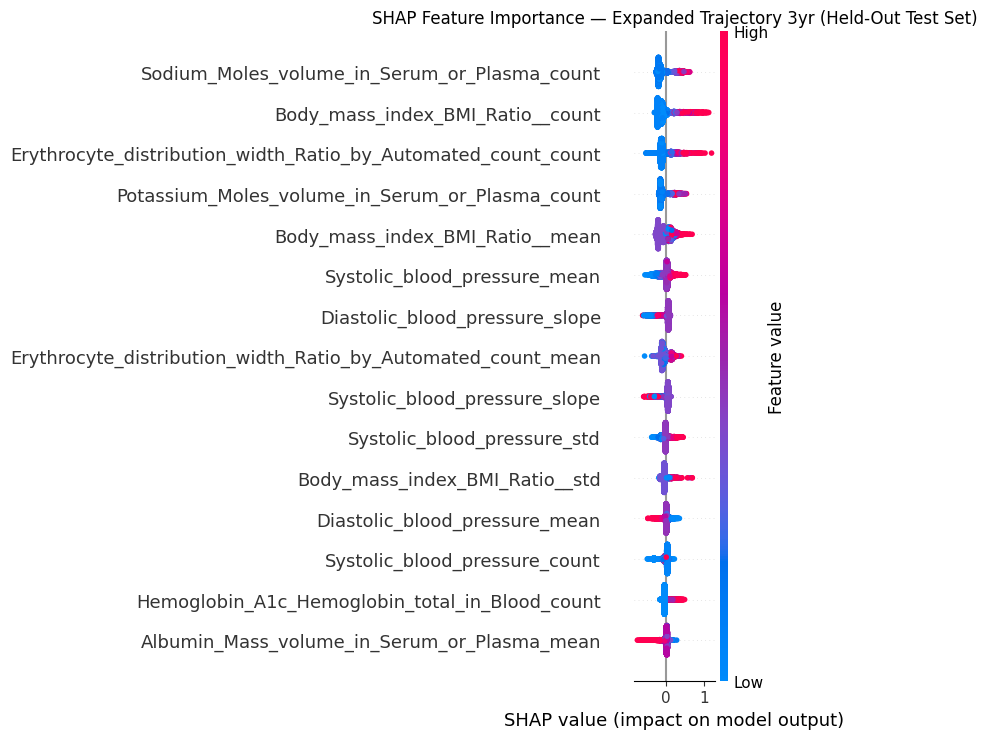

In [59]:
# Beeswarm
shap.summary_plot(
    shap_vals,
    X_shap,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Feature Importance — Expanded Trajectory 3yr (Held-Out Test Set)"
)

plt.tight_layout()

plt.savefig(
    "shap_summary_expanded.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_109/3893443595.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


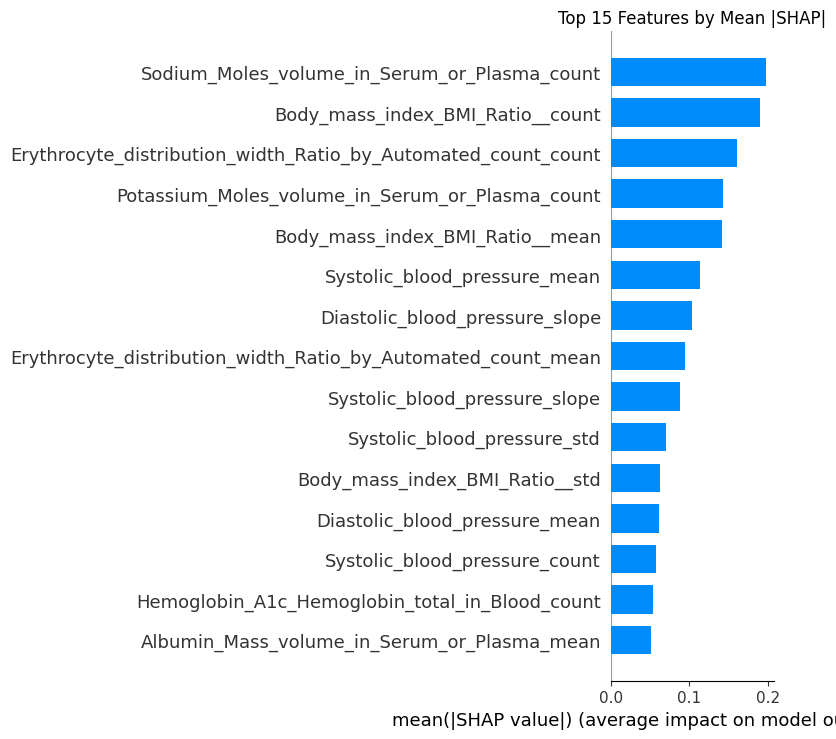

In [60]:
# Bar plot
shap.summary_plot(
    shap_vals,
    X_shap,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title("Top 15 Features by Mean |SHAP|")

plt.tight_layout()

plt.savefig(
    "shap_bar_expanded.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [61]:
mean_shap_exp = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=X_shap.columns
).sort_values(ascending=False)

print("\nTop 15 Most Important Features:")

print(mean_shap_exp.head(15).to_string())


metric_importance_exp = mean_shap_exp.reset_index()
metric_importance_exp.columns = ["feature", "mean_abs_shap"]
metric_importance_exp["metric"] = metric_importance_exp["feature"].apply(
    lambda x: x.split("_")[-1]
)

print("\nMean |SHAP| by metric type:")

print(
    metric_importance_exp
    .groupby("metric")["mean_abs_shap"]
    .mean()
    .sort_values(ascending=False)
    .to_string()
)


Top 15 Most Important Features:
Sodium_Moles_volume_in_Serum_or_Plasma_count                     0.197680
Body_mass_index_BMI_Ratio__count                                 0.189063
Erythrocyte_distribution_width_Ratio_by_Automated_count_count    0.160741
Potassium_Moles_volume_in_Serum_or_Plasma_count                  0.142391
Body_mass_index_BMI_Ratio__mean                                  0.141220
Systolic_blood_pressure_mean                                     0.113275
Diastolic_blood_pressure_slope                                   0.103702
Erythrocyte_distribution_width_Ratio_by_Automated_count_mean     0.093782
Systolic_blood_pressure_slope                                    0.088193
Systolic_blood_pressure_std                                      0.069702
Body_mass_index_BMI_Ratio__std                                   0.063022
Diastolic_blood_pressure_mean                                    0.061946
Systolic_blood_pressure_count                                    0.056949
Hemog

## Sensitivity Analysis: Removing Count Features

Count features may proxy for healthcare utilization rather than biological signal. This analysis tests whether predictive performance persists after their removal.

In [62]:
# Remove utilization features

features_no_count_exp = [
    col for col in traj_3yr_wide_expanded.columns
    if not col.endswith("_count")
]

traj_3yr_no_count_exp = traj_3yr_wide_expanded[features_no_count_exp]


y_true_nc_exp, preds_nc_exp = get_oof_predictions(
    traj_3yr_no_count_exp
)

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.7885568880767329


In [63]:
nc_mean_exp, nc_lo_exp, nc_hi_exp = bootstrap_auc_ci(
    y_true_nc_exp,
    preds_nc_exp
)

print(
    "Expanded Trajectory 3yr (No Count) AUC:",
    round(nc_mean_exp,4),
    f"[{nc_lo_exp:.4f} – {nc_hi_exp:.4f}]"
)

Expanded Trajectory 3yr (No Count) AUC: 0.7885 [0.7859 – 0.7911]


In [64]:
aucs_nc_exp, diff_nc_exp, p_nc_exp = delong_test(
    y_true_traj_exp,
    preds_traj_exp,
    preds_nc_exp
)

print("Full model AUC:", round(aucs_nc_exp[0],4))
print("No-count AUC:", round(aucs_nc_exp[1],4))
print("Difference:", round(diff_nc_exp,4))
print("DeLong p-value:", round(p_nc_exp,6))

Full model AUC: 0.7971
No-count AUC: 0.7886
Difference: 0.0085
DeLong p-value: 0.0


## Calibration Analysis

Calibration assesses whether predicted probabilities match observed event rates — critical for clinical decision-making.

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Uncalibrated: AUC=0.7961 | Brier=0.1742 | AUPRC=0.3825


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/ut

Isotonic: AUC=0.7974 | Brier=0.0828 | AUPRC=0.3873


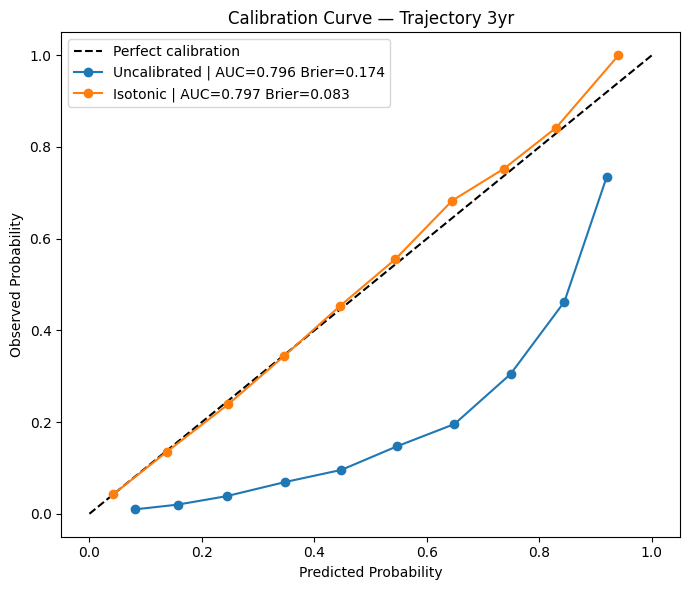

In [10]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt


def evaluate_calibration(df, label="Model"):

    X = df.drop(columns=["person_id", "label"])
    y = df["label"]

    mask = ~X.isna().all(axis=1)
    X, y = X[mask], y[mask]

    imputer = SimpleImputer(strategy="median")

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    X_train = imputer.fit_transform(X_train_raw)
    X_test  = imputer.transform(X_test_raw)

    spw = (y_train == 0).sum() / (y_train == 1).sum()

    base = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        scale_pos_weight=spw,
        random_state=42,
        verbose=-1
    )

    calibrated = CalibratedClassifierCV(
        lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            scale_pos_weight=spw,
            random_state=42,
            verbose=-1
        ),
        method="isotonic",
        cv=5
    )

    fig, ax = plt.subplots(figsize=(7,6))

    ax.plot([0,1],[0,1],"k--",label="Perfect calibration")

    for name, model in [
        ("Uncalibrated", base),
        ("Isotonic", calibrated)
    ]:

        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:,1]

        auc = roc_auc_score(y_test, y_prob)
        brier = brier_score_loss(y_test, y_prob)
        auprc = average_precision_score(y_test, y_prob)

        prob_true, prob_pred = calibration_curve(
            y_test,
            y_prob,
            n_bins=10,
            strategy="uniform"
        )

        ax.plot(
            prob_pred,
            prob_true,
            marker="o",
            label=f"{name} | AUC={auc:.3f} Brier={brier:.3f}"
        )

        print(
            f"{name}: AUC={auc:.4f} | "
            f"Brier={brier:.4f} | "
            f"AUPRC={auprc:.4f}"
        )
    ax.set_xlabel("Predicted Probability")
    ax.set_ylabel("Observed Probability")

    ax.set_title(f"Calibration Curve — {label}")

    ax.legend()

    plt.tight_layout()

    plt.savefig(
        "calibration_comparison_expanded.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

evaluate_calibration(
    traj_3yr_wide_expanded,
    "Trajectory 3yr"
)

## Precision-Recall Analysis (AUPRC)
With ~14% case prevalence, AUPRC provides a more informative view of positive-class performance than AUC-ROC.

Expanded Baseline 3yr AUPRC:   0.3039
Expanded Trajectory 3yr AUPRC: 0.3798


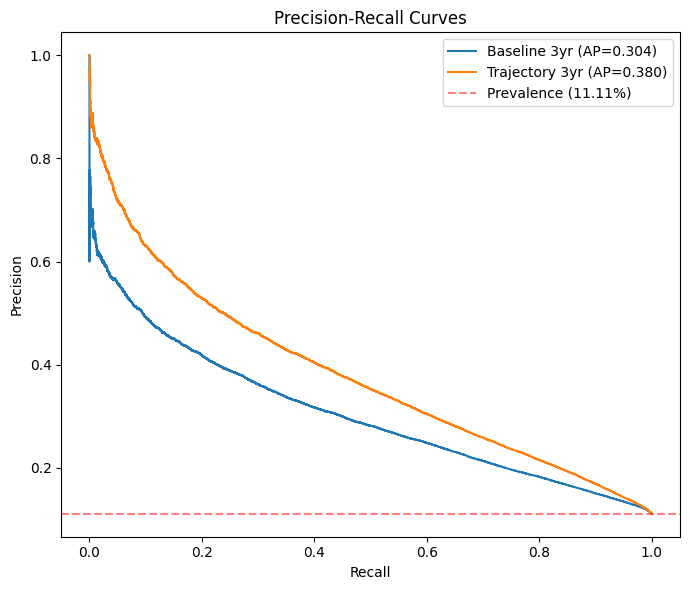

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score


auprc_base_exp = average_precision_score(
    y_true_base_exp,
    preds_base_exp
)

auprc_traj_exp = average_precision_score(
    y_true_traj_exp,
    preds_traj_exp
)

print(f"Expanded Baseline 3yr AUPRC:   {auprc_base_exp:.4f}")
print(f"Expanded Trajectory 3yr AUPRC: {auprc_traj_exp:.4f}")

fig, ax = plt.subplots(figsize=(7,6))

for name, yt, yp in [
    ("Baseline 3yr", y_true_base_exp, preds_base_exp),
    ("Trajectory 3yr", y_true_traj_exp, preds_traj_exp)
]:

    prec, rec, _ = precision_recall_curve(yt, yp)
    ap = average_precision_score(yt, yp)

    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})")


prevalence = y_true_traj_exp.mean()

ax.axhline(
    prevalence,
    color="red",
    linestyle="--",
    alpha=0.5,
    label=f"Prevalence ({prevalence:.2%})"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.set_title("Precision-Recall Curves")

ax.legend()

plt.tight_layout()

plt.savefig(
    "pr_curves_expanded.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Demographics Extraction

In [67]:
import os
import pandas as pd

dataset_person_sql = """
SELECT
    p.person_id,
    p.year_of_birth,
    gc.concept_name AS gender
FROM
    `""" + os.environ["WORKSPACE_CDR"] + """.person` p
LEFT JOIN
    `""" + os.environ["WORKSPACE_CDR"] + """.concept` gc
ON
    p.gender_concept_id = gc.concept_id
"""

person_df = pd.read_gbq(
    dataset_person_sql,
    dialect="standard",
    use_bqstorage_api=("BIGQUERY_STORAGE_API_ENABLED" in os.environ),
    progress_bar_type="tqdm_notebook"
)

person_df.shape

Downloading:   0%|          | 0/633547 [00:00<?, ?rows/s]

(633547, 3)

In [68]:
person_df.to_parquet("person_demographics.parquet", index=False)

## Merge Demographics into Pseudo Cohort

In [69]:
person_df = pd.read_parquet(
    "person_demographics.parquet"
)

pseudo_cohort_expanded = pd.read_parquet(
    "pseudo_cohort_expanded.parquet"
)

cohort_demo_expanded = pseudo_cohort_expanded.merge(
    person_df,
    on="person_id",
    how="left"
)

cohort_demo_expanded.shape

(322409, 5)

In [70]:
cohort_demo_expanded.to_parquet(
    "cohort_demographics_expanded.parquet",
    index=False
)

In [71]:
cohort_demo_expanded["decline_date"] = pd.to_datetime(
    cohort_demo_expanded["decline_date"]
)

cohort_demo_expanded["age_at_index"] = (
    cohort_demo_expanded["decline_date"].dt.year
    - cohort_demo_expanded["year_of_birth"]
)

cohort_demo_expanded[["age_at_index","gender"]].describe()

,age_at_index
count,322409.0
mean,50.637383
std,16.832542
min,2.0
25%,37.0
50%,52.0
75%,64.0
max,103.0


In [72]:
cohort_demo_expanded["gender"].isna().sum()

0

## Demographics-Only Baseline Model
Establishes the predictive floor achievable from age and sex alone, against which lab and trajectory features must improve.

In [73]:
# Build demographics dataset

person_df = pd.read_parquet("person_demographics.parquet")

cohort_demo_expanded = pseudo_cohort_expanded.merge(
    person_df,
    on="person_id",
    how="left"
)

cohort_demo_expanded["decline_date"] = pd.to_datetime(
    cohort_demo_expanded["decline_date"]
)

cohort_demo_expanded["age_at_index"] = (
    cohort_demo_expanded["decline_date"].dt.year
    - cohort_demo_expanded["year_of_birth"]
)

demo_features_expanded = pd.get_dummies(
    cohort_demo_expanded[
        ["person_id","age_at_index","gender","label"]
    ],
    columns=["gender"],
    drop_first=True
)

import re

demo_features_expanded.columns = [
    re.sub(r"[^A-Za-z0-9_]+","_",c)
    for c in demo_features_expanded.columns
]

print(
    "Demographics-only dataset shape:",
    demo_features_expanded.shape
)

print("\nAge summary:")
print(
    cohort_demo_expanded["age_at_index"]
    .describe()
    .round(1)
)

print("\nGender distribution:")
print(
    cohort_demo_expanded["gender"]
    .value_counts()
)

Demographics-only dataset shape: (322409, 11)

Age summary:
count    322409.0
mean         50.6
std          16.8
min           2.0
25%          37.0
50%          52.0
75%          64.0
max         103.0
Name: age_at_index, dtype: Float64

Gender distribution:
gender
Female                                                            198956
Male                                                              117664
PMI: Skip                                                           2330
Not man only, not woman only, prefer not to answer, or skipped      1168
Gender Identity: Non Binary                                         1041
Gender Identity: Transgender                                         504
I prefer not to answer                                               384
Gender Identity: Additional Options                                  361
No matching concept                                                    1
Name: count, dtype: int64


In [74]:
# Run 5 fold CV on demographics-only model
demo_mean_exp, demo_std_exp = run_model_cv(
    demo_features_expanded,
    model_name="Expanded Demographics Only (Age + Sex)"
)


===== Expanded Demographics Only (Age + Sex) =====


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: AUC = 0.6803


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: AUC = 0.6818


...

Fold 3: AUC = 0.6831


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4: AUC = 0.6793


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 5: AUC = 0.6769

Mean AUC: 0.6803 ± 0.0021


In [75]:
# OOF predictions for demographics model
y_true_demo_exp, preds_demo_exp = get_oof_predictions(demo_features_expanded)

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.6800431077806692


In [76]:
# Bootstrap CI
demo_auc_mean_exp, demo_lo_exp, demo_hi_exp = bootstrap_auc_ci(
    y_true_demo_exp,
    preds_demo_exp
)

print(
    f"Demographics-only AUC: {demo_auc_mean_exp:.4f} "
    f"[{demo_lo_exp:.4f} - {demo_hi_exp:.4f}]"
)

Demographics-only AUC: 0.6801 [0.6773 - 0.6830]


## Age/Sex Matched Cohort Design
1:1 matching of cases to controls on gender (exact) and age at index (±2 years) to remove demographic confounding and isolate the contribution of lab trajectory features.

In [77]:
# Prepare cases and controls with demographics
cases_m = cohort_demo_expanded[cohort_demo_expanded["label"] == 1].copy()
controls_m = cohort_demo_expanded[cohort_demo_expanded["label"] == 0].copy()

print(f"Cases available for matching: {len(cases_m)}")
print(f"Controls available for matching: {len(controls_m)}")

Cases available for matching: 35049
Controls available for matching: 287360


In [78]:
# 1:1 Greedy matching on gender (exact) and age (±2 years)
# Store explicit case→control mapping for correct index date assignment

cases_m = cases_m.sort_values(["gender", "age_at_index"]).reset_index(drop=True)
controls_m = controls_m.sort_values(["gender", "age_at_index"]).reset_index(drop=True)

matched_pairs = []
available_controls = controls_m.copy()

for _, case in cases_m.iterrows():

    potential = available_controls[
        (available_controls["gender"] == case["gender"]) &
        (abs(available_controls["age_at_index"] - case["age_at_index"]) <= 2)
    ]

    if len(potential) > 0:

        selected = potential.iloc[0]

        matched_pairs.append({
            "case_id": case["person_id"],
            "control_id": selected["person_id"],
            "case_decline_date": case["decline_date"]
        })

        available_controls = available_controls[
            available_controls["person_id"] != selected["person_id"]
        ]

match_df = pd.DataFrame(matched_pairs)

print(f"Successfully matched: {len(match_df)} pairs")
print(f"Unmatched cases: {len(cases_m) - len(match_df)}")

Successfully matched: 35044 pairs
Unmatched cases: 5


In [79]:
# Build matched cohort with CORRECT index date assignment via explicit mapping

# Cases: use their real decline dates
matched_cases_df = cases_m[
    cases_m["person_id"].isin(match_df["case_id"])
][["person_id", "decline_date", "label", "age_at_index", "gender"]].copy()

# Controls: assign the MATCHED CASE's decline date (not positional)
control_dates = match_df[["control_id", "case_decline_date"]].rename(
    columns={"control_id": "person_id", "case_decline_date": "decline_date"}
)

matched_controls_df = controls_m[
    controls_m["person_id"].isin(match_df["control_id"])
][["person_id", "label", "age_at_index", "gender"]].copy()

matched_controls_df = matched_controls_df.merge(
    control_dates, on="person_id", how="left"
)

# Combine
matched_cohort = pd.concat(
    [matched_cases_df[["person_id", "decline_date", "label"]],
     matched_controls_df[["person_id", "decline_date", "label"]]],
    ignore_index=True
)

matched_cohort.to_parquet("matched_cohort_expanded.parquet", index=False)

print(f"Matched cohort size: {len(matched_cohort)}")
print(f"  Cases:    {(matched_cohort['label']==1).sum()}")
print(f"  Controls: {(matched_cohort['label']==0).sum()}")

Matched cohort size: 70088
  Cases:    35044
  Controls: 35044


In [80]:
# Verify demographic balance after matching
matched_with_demo = matched_cohort.merge(
    cohort_demo_expanded[["person_id", "age_at_index", "gender"]],
    on="person_id", how="left"
)

print("Age at index by group:")
print(matched_with_demo.groupby("label")["age_at_index"].describe().round(1))
print("\nGender distribution by group:")
print(pd.crosstab(matched_with_demo["label"], matched_with_demo["gender"], normalize="index").round(3))

Age at index by group:
         count  mean   std  min   25%   50%   75%    max
label                                                   
0      35044.0  58.1  15.2  6.0  49.0  60.0  69.0   99.0
1      35044.0  60.1  15.2  8.0  51.0  62.0  71.0  101.0

Gender distribution by group:
gender  Female  Gender Identity: Additional Options  \
label                                                 
0        0.613                                0.001   
1        0.613                                0.001   

gender  Gender Identity: Non Binary  Gender Identity: Transgender  \
label                                                               
0                             0.002                         0.001   
1                             0.002                         0.001   

gender  I prefer not to answer  Male  \
label                                  
0                        0.001  0.37   
1                        0.001  0.37   

gender  Not man only, not woman only, prefer not to answer,

## Matched Cohort: Trajectory Features and Evaluation

In [81]:
# Merge matched cohort with labs
labs_matched = measurement_df.merge(
    matched_cohort[["person_id", "decline_date", "label"]],
    on="person_id", how="inner"
)

labs_matched["measurement_datetime"] = pd.to_datetime(labs_matched["measurement_datetime"])
labs_matched["decline_date"] = pd.to_datetime(labs_matched["decline_date"])

# Pre-index only
labs_matched = labs_matched[
    labs_matched["measurement_datetime"] < labs_matched["decline_date"]
]

# 3-year window
labs_matched_3yr = labs_matched[
    labs_matched["measurement_datetime"] >=
    labs_matched["decline_date"] - pd.DateOffset(years=3)
].copy()

print("Matched labs 3yr shape:", labs_matched_3yr.shape)

Matched labs 3yr shape: (5568883, 8)


In [82]:
# Trajectory features for matched cohort (with slope)
labs_matched_3yr["days_before_index"] = (
    labs_matched_3yr["decline_date"] - labs_matched_3yr["measurement_datetime"]
).dt.days

labs_matched_3yr = labs_matched_3yr.sort_values(
    ["person_id", "standard_concept_name", "measurement_datetime"]
)

agg_basic_m = (
    labs_matched_3yr
    .groupby(["person_id", "standard_concept_name"])
    .agg(
        mean=("value_as_number", "mean"),
        std=("value_as_number", "std"),
        first_val=("value_as_number", "first"),
        last_val=("value_as_number", "last"),
        count=("value_as_number", "count")
    )
)

labs_matched_3yr["xy"] = labs_matched_3yr["days_before_index"] * labs_matched_3yr["value_as_number"]
labs_matched_3yr["xx"] = labs_matched_3yr["days_before_index"] ** 2

agg_slope_m = (
    labs_matched_3yr
    .groupby(["person_id", "standard_concept_name"])
    .agg(
        sum_x=("days_before_index", "sum"),
        sum_y=("value_as_number", "sum"),
        sum_xy=("xy", "sum"),
        sum_xx=("xx", "sum"),
        n=("value_as_number", "count")
    )
)

num_m = agg_slope_m["n"] * agg_slope_m["sum_xy"] - agg_slope_m["sum_x"] * agg_slope_m["sum_y"]
den_m = agg_slope_m["n"] * agg_slope_m["sum_xx"] - agg_slope_m["sum_x"] ** 2
agg_slope_m["slope"] = num_m / den_m
agg_slope_m.loc[den_m == 0, "slope"] = np.nan

traj_matched = agg_basic_m.join(agg_slope_m["slope"])
traj_matched["delta"] = traj_matched["last_val"] - traj_matched["first_val"]
traj_matched = traj_matched.reset_index()

# Pivot to wide
traj_m_long = traj_matched.melt(
    id_vars=["person_id", "standard_concept_name"],
    value_vars=["mean", "std", "delta", "slope", "count"],
    var_name="metric", value_name="value"
)
traj_m_long["feature"] = (
    traj_m_long["standard_concept_name"]
    .str.replace(r"[^A-Za-z0-9]+", "_", regex=True)
    + "_" + traj_m_long["metric"]
)

traj_matched_wide = traj_m_long.pivot(
    index="person_id", columns="feature", values="value"
).reset_index()

traj_matched_wide = traj_matched_wide.merge(
    labs_matched_3yr[["person_id", "label"]].drop_duplicates(),
    on="person_id"
)

print("Matched trajectory wide shape:", traj_matched_wide.shape)

Matched trajectory wide shape: (59158, 82)


In [83]:
traj_matched_wide["label"].value_counts()

label
1    33083
0    26075
Name: count, dtype: int64

In [84]:
# CV evaluation on matched cohort
matched_mean, matched_std = run_model_cv(
    traj_matched_wide,
    model_name="Matched Trajectory 3-Year"
)

run_multiple_models_cv(traj_matched_wide, "Matched Trajectory 3yr")


===== Matched Trajectory 3-Year =====


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 1: AUC = 0.7287


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 2: AUC = 0.7267


...

/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [03:10:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [03:10:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [03:10:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [03:10:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [03:10:47] WARNING: /w

XGBoost: 0.7260 ± 0.0070


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM: 0.7271 ± 0.0070


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [85]:
# OOF predictions for matched cohort
y_true_matched, preds_matched = get_oof_predictions(traj_matched_wide)

matched_oof_mean, matched_lo, matched_hi = bootstrap_auc_ci(
    y_true_matched, preds_matched
)

print(f"Matched Trajectory 3yr AUC: {matched_oof_mean:.4f} [{matched_lo:.4f} - {matched_hi:.4f}]")

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.7269763944480963
Matched Trajectory 3yr AUC: 0.7269 [0.7228 - 0.7308]


## Net Reclassification Improvement (NRI)
Evaluates whether the trajectory model correctly reclassifies patients compared to the baseline model at clinically relevant risk thresholds.

In [86]:
import numpy as np

def compute_nri(y_true, pred_baseline, pred_trajectory, threshold=0.20):

    class_b = (pred_baseline >= threshold).astype(int)
    class_t = (pred_trajectory >= threshold).astype(int)

    events = y_true == 1
    nonevents = y_true == 0

    event_up = np.sum((class_t > class_b) & events)
    event_down = np.sum((class_t < class_b) & events)

    nonevent_down = np.sum((class_t < class_b) & nonevents)
    nonevent_up = np.sum((class_t > class_b) & nonevents)

    nri_events = (event_up - event_down) / np.sum(events)
    nri_nonevents = (nonevent_down - nonevent_up) / np.sum(nonevents)

    nri = nri_events + nri_nonevents

    return nri, nri_events, nri_nonevents


print("NRI at various risk thresholds (Trajectory vs Baseline, 3yr):\n")
print(f"{'Threshold':>10}  {'NRI':>8}  {'NRI-events':>12}  {'NRI-nonevents':>14}")
print("-" * 50)

for t in [0.10, 0.15, 0.20, 0.25, 0.30]:

    nri, nri_e, nri_ne = compute_nri(
        y_true_base_exp,
        preds_base_exp,
        preds_traj_exp,
        threshold=t
    )

    print(f"{t:>10.2f}  {nri:>8.4f}  {nri_e:>12.4f}  {nri_ne:>14.4f}")

NRI at various risk thresholds (Trajectory vs Baseline, 3yr):

 Threshold       NRI    NRI-events   NRI-nonevents
--------------------------------------------------
      0.10    0.0071        0.0004          0.0067
      0.15    0.0288       -0.0028          0.0316
      0.20    0.0774       -0.0133          0.0907
      0.25    0.1237       -0.0297          0.1534
      0.30    0.1097       -0.0209          0.1306


## Final Results Summary

In [87]:
from sklearn.metrics import average_precision_score
import pandas as pd

# -------------------------------
# Compute AUPRC values
# -------------------------------

auprc_demo_exp = average_precision_score(
    y_true_demo_exp, preds_demo_exp
)

auprc_base_exp = average_precision_score(
    y_true_base_exp, preds_base_exp
)

auprc_traj_exp = average_precision_score(
    y_true_traj_exp, preds_traj_exp
)

# Matched cohort AUPRC
auprc_matched = average_precision_score(
    y_true_matched, preds_matched
)


# -------------------------------
# Build results table
# -------------------------------

results = pd.DataFrame([

    {
        "Model": "Demographics only",
        "AUC": demo_auc_mean_exp,
        "95% CI": f"[{demo_lo_exp:.3f}-{demo_hi_exp:.3f}]",
        "AUPRC": auprc_demo_exp
    },

    {
        "Model": "Baseline labs (3yr)",
        "AUC": base_mean_exp,
        "95% CI": f"[{base_lo_exp:.3f}-{base_hi_exp:.3f}]",
        "AUPRC": auprc_base_exp
    },

    {
        "Model": "Trajectory (3yr, unmatched)",
        "AUC": traj_mean_exp,
        "95% CI": f"[{traj_lo_exp:.3f}-{traj_hi_exp:.3f}]",
        "AUPRC": auprc_traj_exp
    },

    {
        "Model": "Trajectory (3yr, matched)",
        "AUC": matched_oof_mean,
        "95% CI": f"[{matched_lo:.3f}-{matched_hi:.3f}]",
        "AUPRC": auprc_matched
    }

])


# -------------------------------
# Formatting
# -------------------------------

results["AUC"] = results["AUC"].round(4)
results["AUPRC"] = results["AUPRC"].round(4)


# -------------------------------
# Print results
# -------------------------------

print("=" * 72)
print(" FINAL RESULTS — Predicting Mobility Decline (All of Us, Expanded Labs)")
print("=" * 72)
print(results.to_string(index=False))
print("=" * 72)

 FINAL RESULTS — Predicting Mobility Decline (All of Us, Expanded Labs)
                      Model    AUC        95% CI  AUPRC
          Demographics only 0.6801 [0.677-0.683] 0.2035
        Baseline labs (3yr) 0.7547 [0.752-0.757] 0.3039
Trajectory (3yr, unmatched) 0.7970 [0.794-0.800] 0.3798
  Trajectory (3yr, matched) 0.7269 [0.723-0.731] 0.7664


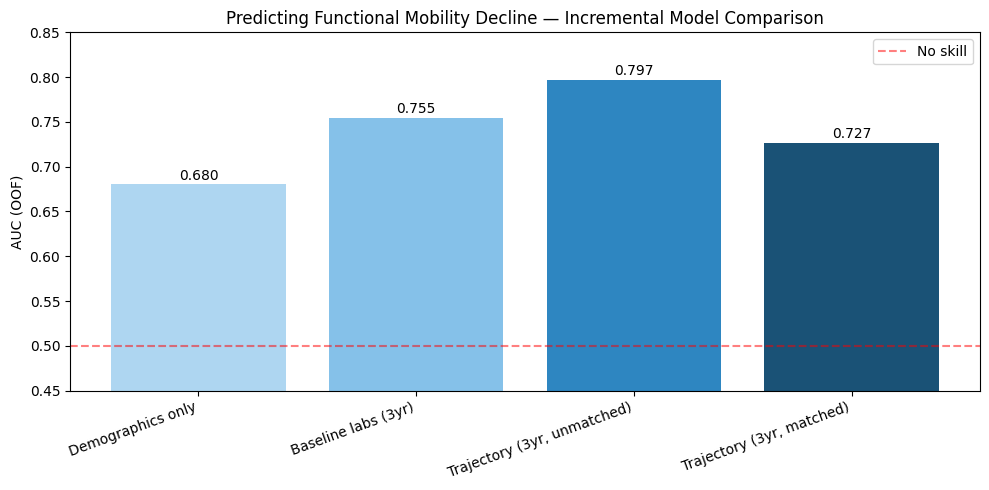

In [88]:
fig, ax = plt.subplots(figsize=(10, 5))

names = results["Model"].values
aucs = results["AUC"].values

colors = ["#AED6F1", "#85C1E9", "#2E86C1", "#1A5276"]

bars = ax.bar(range(len(names)), aucs, color=colors)

ax.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="No skill")

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=20, ha="right")

ax.set_ylabel("AUC (OOF)")
ax.set_title("Predicting Functional Mobility Decline — Incremental Model Comparison")

ax.set_ylim(0.45, 0.85)

for bar, auc in zip(bars, aucs):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{auc:.3f}",
        ha="center",
        fontsize=10
    )

ax.legend()

plt.tight_layout()

plt.savefig(
    "final_results_expanded.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [89]:
print("Matched prevalence:", y_true_matched.mean())

Matched prevalence: 0.5592312113323642


In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import shap
import os

In [2]:
measurement_df = pd.read_parquet("measurement_raw_expanded.parquet")

mobility_df = pd.read_parquet("mobility_condition_raw.parquet")

pseudo_cohort = pd.read_parquet("pseudo_cohort_expanded.parquet")

labs_preindex = pd.read_parquet("labs_preindex_pseudo_expanded.parquet")

labs_2yr = pd.read_parquet("labs_2yr_pseudo_expanded.parquet")

labs_3yr = pd.read_parquet("labs_3yr_pseudo_expanded.parquet")

In [3]:
baseline_2yr_wide_expanded = pd.read_parquet(
    "baseline_2yr_wide_expanded.parquet"
)

baseline_3yr_wide_expanded = pd.read_parquet(
    "baseline_3yr_wide_expanded.parquet"
)

traj_2yr_wide_expanded = pd.read_parquet(
    "traj_2yr_wide_expanded.parquet"
)

traj_3yr_wide_expanded = pd.read_parquet(
    "traj_3yr_wide_expanded.parquet"
)

In [4]:
person_df = pd.read_parquet("person_demographics.parquet")

cohort_demo_expanded = pd.read_parquet(
    "cohort_demographics_expanded.parquet"
)

In [6]:
print(measurement_df.shape)
print(pseudo_cohort.shape)
print(traj_3yr_wide_expanded.shape)

(61490458, 6)
(322409, 3)
(297861, 82)


## Prediction Horizon Analysis — Early Detection Window

In [12]:
def build_horizon_dataset(measurement_df, pseudo_cohort, horizon_months):

    labs_h = measurement_df.merge(
        pseudo_cohort[["person_id","decline_date","label"]],
        on="person_id",
        how="inner"
    )

    labs_h["measurement_datetime"] = pd.to_datetime(labs_h["measurement_datetime"])
    labs_h["decline_date"] = pd.to_datetime(labs_h["decline_date"])

    # ----------------------------
    # Horizon survivor check
    # ----------------------------
    obs_start = (
        measurement_df
        .groupby("person_id")["measurement_datetime"]
        .min()
        .reset_index()
        .rename(columns={"measurement_datetime":"first_lab"})
    )

    labs_h = labs_h.merge(obs_start, on="person_id")

    labs_h = labs_h[
        labs_h["first_lab"] <=
        labs_h["decline_date"] - pd.DateOffset(months=horizon_months)
    ]

    # ----------------------------
    # Remove labs inside prediction window
    # ----------------------------
    labs_h = labs_h[
        labs_h["measurement_datetime"] <
        labs_h["decline_date"] - pd.DateOffset(months=horizon_months)
    ]

    # ----------------------------
    # Still restrict to 3-year observation window
    # ----------------------------
    labs_h = labs_h[
        labs_h["measurement_datetime"] >=
        labs_h["decline_date"] - pd.DateOffset(years=3)
    ].copy()

    print(f"\nHorizon {horizon_months}m labs shape:", labs_h.shape)

    return labs_h

In [13]:
def build_trajectory_features(labs_df):

    labs_df["days_before_index"] = (
        labs_df["decline_date"] - labs_df["measurement_datetime"]
    ).dt.days

    labs_df = labs_df.sort_values(
        ["person_id","standard_concept_name","measurement_datetime"]
    )

    # Basic aggregates
    agg_basic = (
        labs_df
        .groupby(["person_id","standard_concept_name"])
        .agg(
            mean=("value_as_number","mean"),
            std=("value_as_number","std"),
            first_val=("value_as_number","first"),
            last_val=("value_as_number","last"),
            count=("value_as_number","count")
        )
    )

    labs_df["xy"] = labs_df["days_before_index"] * labs_df["value_as_number"]
    labs_df["xx"] = labs_df["days_before_index"] ** 2

    agg_slope = (
        labs_df
        .groupby(["person_id","standard_concept_name"])
        .agg(
            sum_x=("days_before_index","sum"),
            sum_y=("value_as_number","sum"),
            sum_xy=("xy","sum"),
            sum_xx=("xx","sum"),
            n=("value_as_number","count")
        )
    )

    num = agg_slope["n"]*agg_slope["sum_xy"] - agg_slope["sum_x"]*agg_slope["sum_y"]
    den = agg_slope["n"]*agg_slope["sum_xx"] - agg_slope["sum_x"]**2

    agg_slope["slope"] = num / den
    agg_slope.loc[den == 0,"slope"] = np.nan

    traj = agg_basic.join(agg_slope["slope"])
    traj["delta"] = traj["last_val"] - traj["first_val"]
    traj = traj.reset_index()

    # Convert to wide
    traj_long = traj.melt(
        id_vars=["person_id","standard_concept_name"],
        value_vars=["mean","std","delta","slope","count"],
        var_name="metric",
        value_name="value"
    )

    traj_long["feature"] = (
        traj_long["standard_concept_name"]
        .str.replace(r"[^A-Za-z0-9]+","_",regex=True)
        + "_" + traj_long["metric"]
    )

    traj_wide = traj_long.pivot(
        index="person_id",
        columns="feature",
        values="value"
    ).reset_index()

    traj_wide = traj_wide.merge(
        labs_df[["person_id","label"]].drop_duplicates(),
        on="person_id"
    )

    return traj_wide

In [21]:
horizons = [3,6,9,12]

horizon_results = []

for h in horizons:

    labs_h = build_horizon_dataset(measurement_df, pseudo_cohort, h)

    traj_h = build_trajectory_features(labs_h)

    print("Trajectory dataset shape:", traj_h.shape)

    y_true_h, preds_h = get_oof_predictions(traj_h)

    mean_auc, lo, hi = bootstrap_auc_ci(y_true_h, preds_h)

    auprc = average_precision_score(y_true_h, preds_h)

    horizon_results.append({
        "Horizon (months)": h,
        "AUC": mean_auc,
        "CI": f"[{lo:.3f}-{hi:.3f}]",
        "AUPRC": auprc
    })


Horizon 3m labs shape: (13394489, 9)
Trajectory dataset shape: (261508, 82)


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.7679679716925891

Horizon 6m labs shape: (11611072, 9)
Trajectory dataset shape: (240893, 82)


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.7586577274016224

Horizon 9m labs shape: (10024380, 9)
Trajectory dataset shape: (222922, 82)


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.7489309459912066

Horizon 12m labs shape: (8583333, 9)
Trajectory dataset shape: (206680, 82)


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


OOF AUC: 0.7397831381292171


In [22]:
horizon_results_df = pd.DataFrame(horizon_results)

horizon_results_df["AUC"] = horizon_results_df["AUC"].round(4)
horizon_results_df["AUPRC"] = horizon_results_df["AUPRC"].round(4)

print("\nEarly Detection Horizon Results")
print(horizon_results_df)


Early Detection Horizon Results
   Horizon (months)     AUC             CI   AUPRC
0                 3  0.7680  [0.765-0.771]  0.3390
1                 6  0.7586  [0.756-0.762]  0.3373
2                 9  0.7489  [0.746-0.752]  0.3354
3                12  0.7398  [0.737-0.743]  0.3322


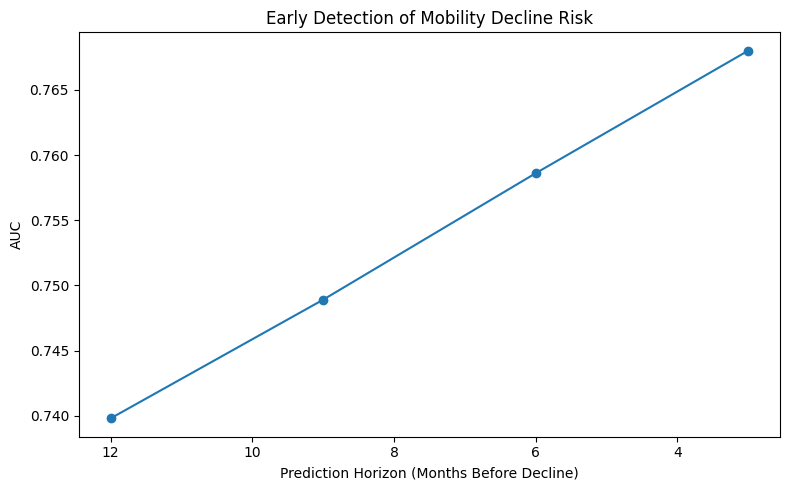

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
    horizon_results_df["Horizon (months)"],
    horizon_results_df["AUC"],
    marker="o"
)

plt.xlabel("Prediction Horizon (Months Before Decline)")
plt.ylabel("AUC")
plt.title("Early Detection of Mobility Decline Risk")

plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()